In [1]:
import numpy as np 
from itertools import product 
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
import cv2
import copy

In [4]:
# #* Special treatment: get the null space of the centroids matrix.
img_ind = 1
img_ind_filter = '1'
centre_list_buffer = np.empty((0,2))

for i,j in product(range(3), repeat=2):
    split_ind = f'_{i}{j}'
    cent_all = np.load(f'CrCoNi-231101/{img_ind}/{img_ind}_dotted-raw{split_ind}.npy')[:,-2:]
    cent_filt = np.load(f'CrCoNi-231101/{img_ind_filter}/{img_ind_filter}_dotted-filter2{split_ind}.npy')[:,-2:]

    delete_ind = []
    for i_ in range(len(cent_all)):
        dis_min = np.min(np.linalg.norm(cent_filt-cent_all[i_], axis=1))
        if dis_min < 4:
            delete_ind.append(i_)
            
    new_centre_list = np.delete(cent_all, np.array(delete_ind), axis=0)
    new_centre_list += np.array([i*700, j*700])
    
    centre_list_buffer = np.concatenate((centre_list_buffer, new_centre_list), axis=0)

In [5]:
img_denote = 'CrCoNi-231101'
img_ind = '1' #TODO important

#* remove the duplicated dots 
x_res = centre_list_buffer[:,0]-centre_list_buffer[:,0].reshape(-1,1)
y_res = centre_list_buffer[:,1]-centre_list_buffer[:,1].reshape(-1,1)
d_res = np.tril(np.sqrt(x_res**2+y_res**2))
delete_ind = np.where((d_res > 1e-3) & (d_res < 9)) #* threshold be set to 4
centre_list_buffer = np.delete(centre_list_buffer, delete_ind[0], axis=0)


np.save(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw.npy', centre_list_buffer)

In [ ]:
%matplotlib inline 
def rot(theta, mat_raw):
    rot_mat = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)],
    ])
    
    mat_new = np.dot(mat_raw, rot_mat)
    return mat_new

fig, ax = plt.subplots(figsize=(20,20))

img_fin_pth = f'CrCoNi-231101/{img_ind}/{img_ind}_dotted_line_pure_polygon-filter_FIN.bmp'
img_raw_pth = f'CrCoNi-231101/1-raw-raw.bmp'
img_fin = cv2.imread(img_fin_pth, cv2.IMREAD_GRAYSCALE)
img_raw = cv2.imread(img_raw_pth, cv2.IMREAD_GRAYSCALE)
min_bound, max_bound = 0, img_raw.shape[0]
dark_zone = np.zeros_like(img_fin)

atom_radius = 2
sample_num = atom_radius*4

kernel_list = np.array(list(product(np.linspace(-atom_radius, atom_radius,sample_num), repeat=2)))
kernel_list = rot(np.deg2rad(-33.2), kernel_list)

#TODO load the perfect matrix
centre_calib = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw_calib.npy')
centre_recog_raw = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw.npy')

intensity_list = []
centre_intlist, centre_floatlist = [], []
for count, centre_ in enumerate(centre_calib):
    
    centre_singlept = np.round(centre_).astype(int)
    centre_singlept = np.clip(centre_singlept, min_bound, max_bound-1)
    
    centre_kernel = np.unique(np.round(centre_ + kernel_list).astype(int), axis=0)
    centre_kernel = np.clip(centre_kernel, min_bound, max_bound-1)
    
    raw_kernel = np.unique(np.round(centre_recog_raw[count] + kernel_list).astype(int), axis=0)
    raw_kernel = np.clip(raw_kernel, min_bound, max_bound-1)
    
    dark_zone[centre_singlept[0], centre_singlept[1]] = np.mean(
        img_raw[raw_kernel[:,0], raw_kernel[:,1]])
    
    intensity_list.append(np.mean(img_raw[raw_kernel[:,0], raw_kernel[:,1]]))
    centre_intlist.append(centre_singlept)
    centre_floatlist.append(centre_)
centre_intlist = np.array(centre_intlist)
centre_floatlist = np.array(centre_floatlist)

#* Gamma
a = 1
gamma = 1
dark_zone = a*np.power(dark_zone, gamma)
dark_zone = (dark_zone-np.min(dark_zone))/(np.max(dark_zone)-np.min(dark_zone))*255

#* Contrast and brightness
alpha, beta = 1, 0
dark_zone = np.clip(dark_zone*alpha + beta, 0, 255).astype(np.uint8)

intensity_list = dark_zone[centre_intlist[:,0], centre_intlist[:,1]]

plt.imshow(dark_zone, cmap='RdBu_r')
plt.colorbar()

plt.show()

In [ ]:
cv2.imwrite('CrCoNi-231101/1/1_dotted-raw.png', dark_zone)

In [ ]:
%matplotlib inline 
fig, ax = plt.subplots(figsize=(20,20))

#* rotate the float centre list by 33.2 degree and draw it on new canvas
deg = 33.200233
centre_floatlist_norm = rot(np.deg2rad(deg), centre_floatlist)
centre_floatlist_norm -= np.array([np.min(centre_floatlist_norm[:,0]), np.min(centre_floatlist_norm[:,1])])
canvas_rot = np.zeros((np.max(centre_floatlist_norm[:,0]).astype(int)+2, np.max(centre_floatlist_norm[:,1]).astype(int)+2))
canvas_rot[np.round(centre_floatlist_norm[:,0]).astype(int), np.round(centre_floatlist_norm[:,1]).astype(int)] = intensity_list

plt.imshow(canvas_rot, cmap='RdBu_r')
plt.colorbar()

plt.show()

In [ ]:
cv2.imwrite('CrCoNi-231101/1/1_dotted-raw_rot.png', canvas_rot)

(array([1079.,  605., 1067.,  444., 1094.,  392.,  697.,  706.,  818.,
        1171.]),
 array([  1. ,  26.4,  51.8,  77.2, 102.6, 128. , 153.4, 178.8, 204.2,
        229.6, 255. ]),
 <BarContainer object of 10 artists>)

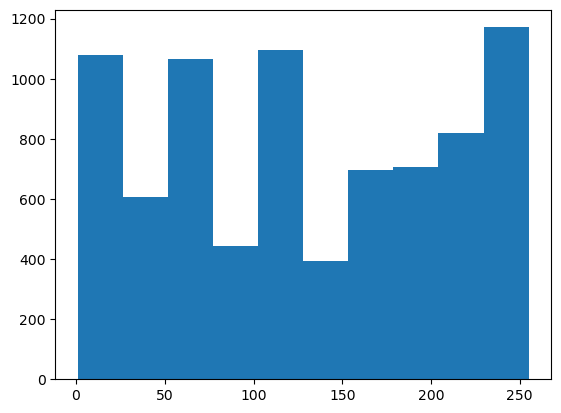

In [151]:
dark_zone_nonzero_raw = dark_zone_raw[dark_zone_raw > 0]
plt.hist(dark_zone_nonzero_raw, bins=10)

(array([   9.,   93.,  199.,  404.,  642., 1213., 2068., 1240., 2058.,
         564.]),
 array([189. , 195.6, 202.2, 208.8, 215.4, 222. , 228.6, 235.2, 241.8,
        248.4, 255. ]),
 <BarContainer object of 10 artists>)

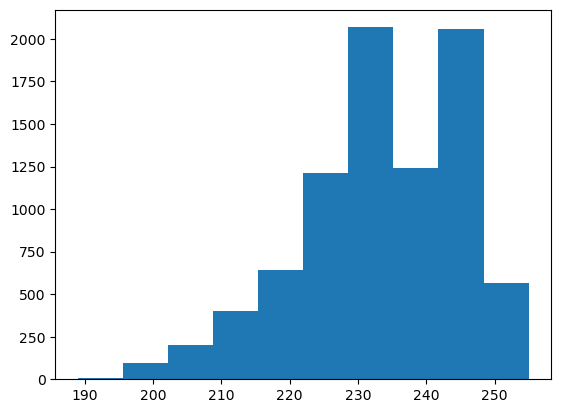

In [7]:
dark_zone_nonzero = dark_zone[dark_zone>0]
plt.hist(dark_zone_nonzero, bins=10)

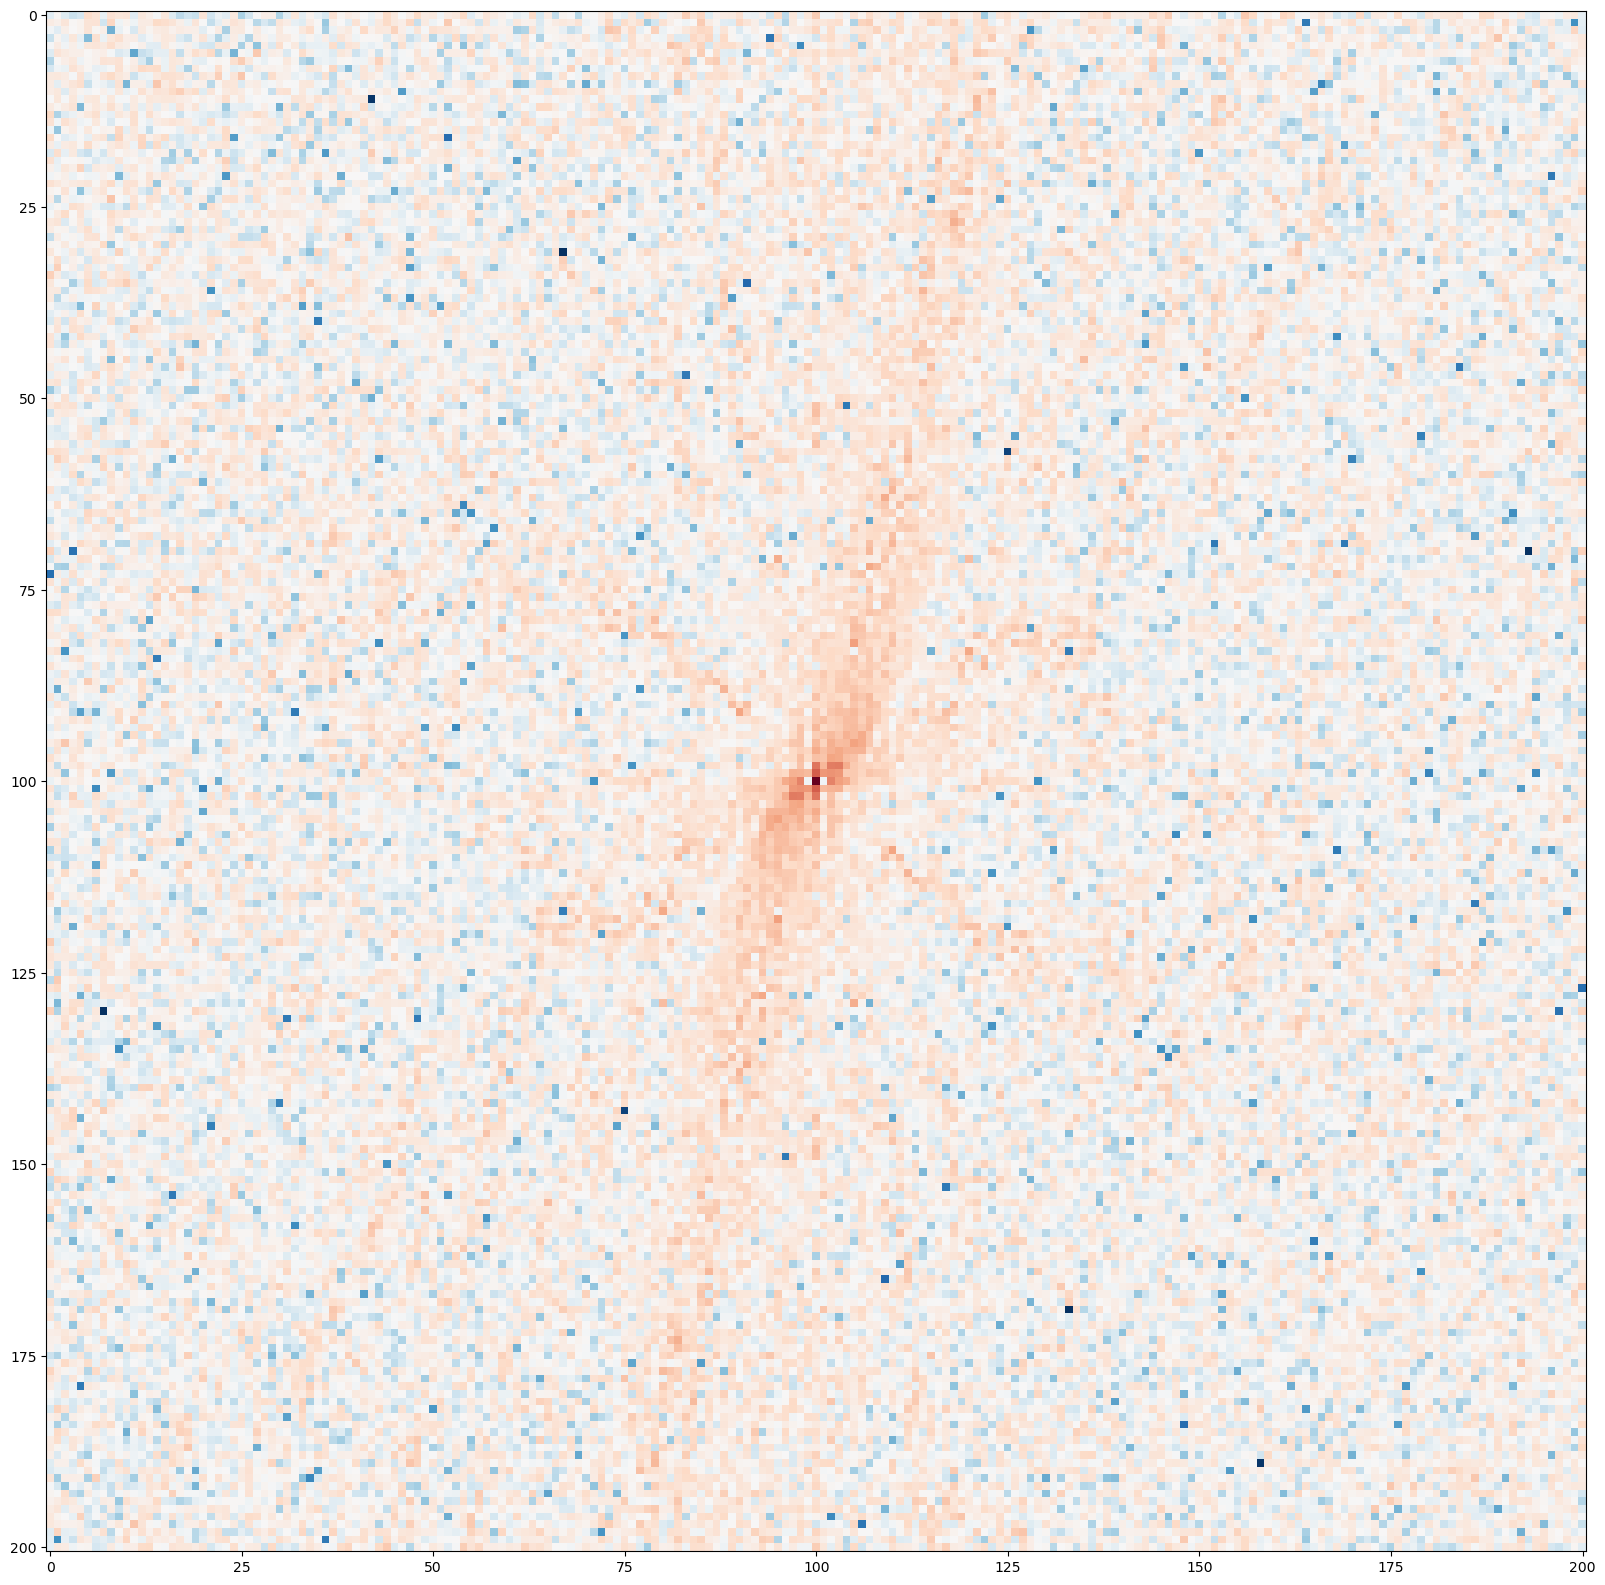

In [11]:
def fft(centre, intensity, k_range, kmap_size):
    # kpt_map = np.zeros((kmap_size, kmap_size))
    intensity = intensity.reshape(1,-1)
    kpt_list = np.array(list(product(np.linspace(-k_range,k_range,kmap_size), repeat=2)))
    
    n_list = np.arange(len(centre))/len(centre)
    
    k_intensity = np.sum(intensity*np.exp(-2*np.pi*1j*np.dot(kpt_list, centre.T)*n_list), axis=1)
    kpt_map = k_intensity.reshape(kmap_size, kmap_size)    
    
    return np.abs(kpt_map)

fft_map = fft(centre_calib, intensity_list, k_range=0.35,
              kmap_size=201)
fft_map = np.log(fft_map+1)
fft_map = (fft_map-np.min(fft_map))/(np.max(fft_map)-np.min(fft_map))*255

fig, ax = plt.subplots(figsize=(20,20))
plt.imshow(fft_map, cmap='RdBu_r')

In [ ]:
%matplotlib inline 
fig, ax = plt.subplots(figsize=(15, 15))

# dark_zone_pth = 'CrCoNi-231101/1-darkzone-rotate.png'
# dark_zone = cv2.imread(dark_zone_pth, cv2.IMREAD_GRAYSCALE)
# dark_zone = canvas_rot
img_fft = fft2(dark_zone)
img_fft_shift = fftshift(img_fft)
img_fft_show = np.log(np.abs(img_fft_shift))

#* Gamma
a = 1
gamma = 1
img_fft_show = a*np.power(img_fft_show, gamma)
img_fft_show = (img_fft_show-np.min(img_fft_show))/(np.max(img_fft_show)-np.min(img_fft_show))*255

 #* Contrast and brightness
alpha, beta = 1, 0
img_fft_show = img_fft_show*alpha + beta

#* bithereshold, p-value = 0.99
count, intensity = np.histogram(img_fft_show, bins=2048)
count_cumsum = np.cumsum(count)
intensity_lowb = intensity[np.where(count_cumsum>=0.99*count_cumsum[-1])[0]][0]
ret_fft, img_fft_show_bithre = cv2.threshold(img_fft_show,intensity_lowb,
                                             255,cv2.THRESH_BINARY)

display_range = 300
illust_zone = [1024-display_range, 1024+display_range]
plt.imshow(img_fft_show_bithre[illust_zone[0]:illust_zone[1],
                               illust_zone[0]:illust_zone[1]], cmap='RdBu_r')
plt.text(display_range-10, display_range-10, f'(000)', fontsize=15, color='green', alpha=0.5)
plt.colorbar()

plt.show()

In [ ]:
plt.hist(img_fft_show.flatten(), bins=200, color='r', alpha=0.25)